<a href="https://colab.research.google.com/github/sakshammverma/finetuing_llm/blob/main/preference_based_dpo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download a pretrained BASEMODEL(LLAMA) \
Non instruction fine tuning on plain text() \
Instruction fine tuning on a instruction dataset \
Alignment preference

In [ ]:

from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

In [ ]:
model = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model)

In [ ]:
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

In [ ]:
import zipfile
import os

zip_path = '/content/tinyllama-instruction.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
model_path = '/content/checkpoint-3'
instruction_model = AutoModelForCausalLM.from_pretrained(model_path, device_map = "auto")


In [ ]:
prompt = "Explain how ai is improving drug discovery and development in pharmaseutical industry"

In [ ]:

inputs= tokenizer(prompt, return_tensors = "pt").to("cuda")

In [ ]:
outputs = instruction_model.generate(
    **inputs,
    max_new_tokens = 100,
    temperature = 0.8,
    top_p = 0.9,
    do_sample = True,
    repetition_penalty = 1.1
)

In [ ]:

print("\n Model Output: \n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

# Starting with preference based tuning


In [ ]:
!pip install -U trl

In [ ]:
!pip install -U bitsandbytes


In [ ]:
from trl import DPOTrainer
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import PeftModel
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

In [ ]:
base_model = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"


In [ ]:
instruction_checkpoint = '/content/checkpoint-3'

In [ ]:
dataset = load_dataset('csv', data_files='/content/pharma_preference_data.csv', split = 'train')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model)

In [ ]:
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

get_peft_model() --> Creates new lora during training

PeftModel.from_pretrained() --> load entirely trained lora for further training or inference


In [ ]:

lora_config = LoraConfig(
    task_type = TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

In [ ]:
base_model

In [ ]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model = AutoModelForCausalLM.from_pretrained(base_model, quantization_config = bnb_config, device_map = 'auto')

In [ ]:
model = PeftModel.from_pretrained(model, instruction_checkpoint)

In [ ]:
# model = model.merge_and_unload()

In [ ]:
model.save_pretrained('/my-lora-adapter')

In [ ]:
import torch
base_model_reload = AutoModelForCausalLM.from_pretrained(base_model,
                                                         torch_dtype=torch.float16,
                                                         device_map = 'auto')

In [ ]:
base_model_reload

In [ ]:
model = PeftModel.from_pretrained(base_model_reload, '/my-lora-adapter')

In [ ]:
merged_model = model.merge_and_unload()

In [ ]:
pref_model_lora = get_peft_model(merged_model,lora_config)


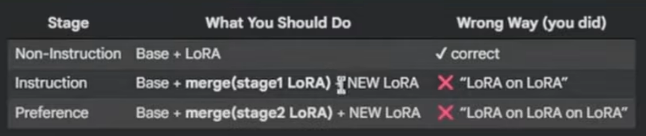

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from trl import DPOTrainer, DPOConfig


In [ ]:
dpo_args = DPOConfig(
    output_dir = './llama-preference-alignment',
    learning_rate = 2e-5,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 8,
    num_train_epochs = 1,
    beta = 0.1,
    report_to = [],
    logging_dir = None,
    loss_type = 'sigmoid',
    remove_unused_columns = False
)

In [ ]:
trainer = DPOTrainer(
    model = pref_model_lora,
    ref_model = None,
  args = dpo_args,
  processing_class = tokenizer,
  train_dataset = dataset,
)

In [ ]:
def format_dpo(example):
    return {
        "prompt": example["prompt"],
        "chosen": example["chosen"] + tokenizer.eos_token,
        "rejected": example["rejected"] + tokenizer.eos_token,
    }

In [ ]:
formatted_data = dataset.map(format_dpo)

In [ ]:
trainer.train()

In [ ]:
prompt = "I feel anxiety evertime i go to sleep what should i do"

In [ ]:
inputs= tokenizer(prompt, return_tensors = "pt").to("cuda")

In [ ]:
outputs = pref_model_lora.generate(
    **inputs,
    max_new_tokens = 100,
    temperature = 0.8,
    top_p = 0.9,
    do_sample = True,
    repetition_penalty = 1.1
)

In [ ]:

print("\n Model Output: \n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))